### Student Information
Name: 沈柔萱

Student ID: NTNU-41223211L

GitHub ID: shampoo-oo

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [1]:
### Begin Assignment Here
# test code for environment setup
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
# If you get "ModuleNotFoundError: No module named 'PAMI'"
# run the following in a new Jupyter cell:
# !pip3 install PAMI
import PAMI
import umap

# TEST necessary for when working with external scripts
%load_ext autoreload
%autoreload 2

import sys

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### load data and data preparation

In [2]:
data= pd.read_csv("newdataset/Reddit-stock-sentiment.csv")

print('''
type: comment/post;
subreddit: 論壇;
upvote: 按讚, comment 沒有downvotes/upvote_ratio,負的upvote就是倒讚， post才有三個指標
subjectivity: 情緒分析
polority: 情緒極性
sentiment 情緒標籤
label: 目標情緒標籤
=========================================================================================
想要做甚麼?
1. label分的類跟upvote的關係圖
2. label值 = 1, 0, -1 的text和title中，統計用詞/標點，看有沒有特殊排名，然後做文字雲之類的
3. label的分類和所屬論壇的比例圖 
=========================================================================================
要做甚麼?
1.合併upvote, downvotes(相減，空值補0)
2.text, title詞條split，然後做出現頻率排名
3.敏感字詞篩選(?

''')
data



type: comment/post;
subreddit: 論壇;
upvote: 按讚, comment 沒有downvotes/upvote_ratio,負的upvote就是倒讚， post才有三個指標
subjectivity: 情緒分析
polority: 情緒極性
sentiment 情緒標籤
label: 目標情緒標籤
想要做甚麼?
1. label分的類跟upvote的關係圖
2. label值 = 1, 0, -1 的text和title中，統計用詞/標點，看有沒有特殊排名，然後做文字雲之類的
3. label的分類和所屬論壇的比例圖 
要做甚麼?
1.合併upvote, downvotes(相減，空值補0)
2.text, title詞條split，然後做出現頻率排名
3.敏感字詞篩選(?




,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,comment,2021-06-30 4:06:06,h3iv6pq,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Ordinary-Office9180,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,Invest now it is going to shoot up tomorrow,0.000000,0.000000,0.0,['tomorrow'],1.0
843,comment,2025-04-11 5:01:24,mmijiuz,StockMarket,$ U.S. dollar value (crashing),lulububudu,https://i.redd.it/atvlo83gk4ue1.jpeg,2,NaN,NaN,Where can I read this?,0.000000,0.000000,0.0,[],0.0
844,post,2025-03-24 12:30:39,1jipi4v,stockstobuytoday,Analyst Recommendations,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,0.0,1.00,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.000000,0.000000,0.0,"['Analyst', 'Nasdaq', 'Stock', 'Upgrades', 'Do...",0.0
845,comment,2025-04-11 20:13:26,mmmely7,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,yes_ur_wrong,https://www.reddit.com/r/wallstreetbets/commen...,10,NaN,NaN,i sold my puts so i expect cheeto to declare w...,0.000000,0.000000,0.0,"['war', 'denmark', 'cheeto', 'i']",-1.0


In [3]:
print("篩選出我需要的欄位")
X= data[['subreddit', 'upvotes','downvotes', 'title','text', "label"]].copy()
X.head()

篩選出我需要的欄位


,subreddit,upvotes,downvotes,title,text,label
0,wallstreetbets,0,NaN,Retardation is on the menu boys! WSB is so back,Calls on retards,-1.0
1,wallstreetbets,-15,NaN,Retail giant TARGET has now declined for 10 co...,Stunt as in like why did they even make a big ...,0.0
2,StockMarket,1,NaN,How do you feel about a sitting president maki...,Seeing lots of red in the ticker.,0.0
3,stockstobuytoday,30,0.0,Who knows more? $VMAR,Vision Marine Technologies Inc. is rewriting t...,1.0
4,StockMarket,1,NaN,The Trump administration is begging Xi Jinping...,He didn’t say thank you.,-1.0


In [4]:
import helpers.data_mining_helpers as dmh
X=X.fillna(0)
X.isnull().apply(lambda x: dmh.check_missing_values(x))
X.isna().apply(lambda x: dmh.check_missing_values(x))

,subreddit,upvotes,downvotes,title,text,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0


In [5]:
print("整理欄位，統計總共的按讚/倒讚數")
X["vote"]= X["upvotes"]-X["downvotes"]
X=X.drop("upvotes", axis=1)
X=X.drop("downvotes", axis=1)

X.head()

整理欄位，統計總共的按讚/倒讚數


,subreddit,title,text,label,vote
0,wallstreetbets,Retardation is on the menu boys! WSB is so back,Calls on retards,-1.0,0.0
1,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Stunt as in like why did they even make a big ...,0.0,-15.0
2,StockMarket,How do you feel about a sitting president maki...,Seeing lots of red in the ticker.,0.0,1.0
3,stockstobuytoday,Who knows more? $VMAR,Vision Marine Technologies Inc. is rewriting t...,1.0,30.0
4,StockMarket,The Trump administration is begging Xi Jinping...,He didn’t say thank you.,-1.0,1.0


### Sample

In [6]:
X_sample = X.sample(n=50)
print(len(X_sample))
X_sample[::10][0:5]

50


,subreddit,title,text,label,vote
645,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,Peasant dont even know fartcoin is up 89% thi...,0.0,8.0
14,stocks,r/Stocks Daily Discussion & Fundamentals Frida...,USA begging China to call them,0.0,8.0
691,StockMarket,Data Shows US Allies—Not China—Dumping Treasuries,"They're playing 3D chess, while the U.S. plays...",1.0,6.0
248,StockMarket,How do you feel about a sitting president maki...,Pelosi and several others did the same thing.,0.0,1.0
261,stockstobuytoday,The stock market's unexpected performance unde...,you can’t be serious. ‘unexpected.’,0.0,1.0


label
 0.0    423
-1.0    315
 1.0    109
Name: count, dtype: int64
label
 0.0    24
-1.0    16
 1.0    10
Name: count, dtype: int64


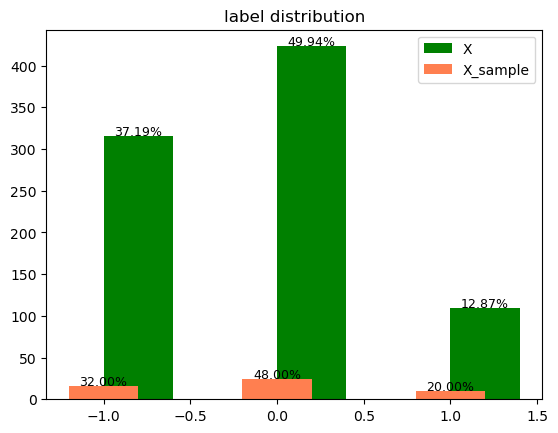


在經過取sample和畫圖之後，發現取sample後的資料分布，與原資料不同。
故在後續使用樣本時，應該住次到此問題的存在。



In [7]:
import matplotlib.pyplot as plt

print(X.label.value_counts())
print(X_sample.label.value_counts())

x_o_line = X["label"]
x_s_line = X_sample["label"]

x_o = x_o_line.value_counts()
x_s = x_s_line.value_counts()

x_o_prop = x_o / x_o.sum()
x_s_prop = x_s / x_s.sum()

plt.ylim(0, max(x_o.max(), x_s.max()) + 20)
plt.title('label distribution', fontsize=12)

# 畫圖
bars1 = plt.bar(
        x_o.index,
        x_o.values,
        width=0.4,
        align='edge',
        color='g',
        label='X'
)
bars2 = plt.bar(
        x_s.index,
        x_s.values,
        width=0.4,
        align='center',
        color='coral',
        label='X_sample'
)

for bar, prop in zip(bars1, x_o_prop):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{prop:.2%}",
        ha='center',
        fontsize=9,
        color='black'
    )

for bar, prop in zip(bars2, x_s_prop):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{prop:.2%}",
        ha='center',
        fontsize=9,
        color='black'
    )

plt.legend()
plt.show()

print('''
在經過取sample和畫圖之後，發現取sample後的資料分布，與原資料不同。
故在後續使用樣本時，應該住次到此問題的存在。
''')

### feature creat

In [8]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
print("將句子拆成字")
X['title_p'] = X['title'].apply(lambda x: dmh.tokenize_text(x))
X['text_p'] = X['text'].apply(lambda x: dmh.tokenize_text(x))
X

將句子拆成字


,subreddit,title,text,label,vote,title_p,text_p
0,wallstreetbets,Retardation is on the menu boys! WSB is so back,Calls on retards,-1.0,0.0,"[Retardation, is, on, the, menu, boys, !, WSB,...","[Calls, on, retards]"
1,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Stunt as in like why did they even make a big ...,0.0,-15.0,"[Retail, giant, TARGET, has, now, declined, fo...","[Stunt, as, in, like, why, did, they, even, ma..."
2,StockMarket,How do you feel about a sitting president maki...,Seeing lots of red in the ticker.,0.0,1.0,"[How, do, you, feel, about, a, sitting, presid...","[Seeing, lots, of, red, in, the, ticker, .]"
3,stockstobuytoday,Who knows more? $VMAR,Vision Marine Technologies Inc. is rewriting t...,1.0,30.0,"[Who, knows, more, ?, $, VMAR]","[Vision, Marine, Technologies, Inc., is, rewri..."
4,StockMarket,The Trump administration is begging Xi Jinping...,He didn’t say thank you.,-1.0,1.0,"[The, Trump, administration, is, begging, Xi, ...","[He, didn, ’, t, say, thank, you, .]"
...,...,...,...,...,...,...,...
842,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Invest now it is going to shoot up tomorrow,1.0,1.0,"[$, MRIN, Marin, Software, killed, it, today, ...","[Invest, now, it, is, going, to, shoot, up, to..."
843,StockMarket,$ U.S. dollar value (crashing),Where can I read this?,0.0,2.0,"[$, U.S., dollar, value, (, crashing, )]","[Where, can, I, read, this, ?]"
844,stockstobuytoday,Analyst Recommendations,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.0,1.0,"[Analyst, Recommendations]","[Upgrades, ,, Downgrades, [, Stock, Analyst, R..."
845,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,i sold my puts so i expect cheeto to declare w...,-1.0,10.0,"[Weekend, Discussion, Thread, for, the, Weeken...","[i, sold, my, puts, so, i, expect, cheeto, to,..."


### 問題根源要處理countvert轉換問題?

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect_title = CountVectorizer()
count_vect_text = CountVectorizer()

X_counts_title = count_vect_title.fit_transform(X.title) #learn the vocabulary and return document-term matrix
print(X_counts_title[1])
print("====================")

X_counts_text = count_vect_text.fit_transform(X.text) #learn the vocabulary and return document-term matrix
print(X_counts_text[1])


  (0, 422)	1
  (0, 215)	1
  (0, 494)	1
  (0, 234)	1
  (0, 353)	1
  (0, 154)	1
  (0, 198)	1
  (0, 3)	1
  (0, 124)	1
  (0, 575)	1
  (0, 279)	1
  (0, 297)	1
  (0, 301)	1
  (0, 481)	1
  (0, 264)	1
  (0, 246)	1
  (0, 3696)	1
  (0, 388)	1
  (0, 2024)	2
  (0, 2310)	1
  (0, 4244)	1
  (0, 1168)	1
  (0, 3858)	1
  (0, 1409)	1
  (0, 2402)	1
  (0, 538)	1
  (0, 1083)	1
  (0, 175)	2
  (0, 3628)	1
  (0, 2161)	1
  (0, 3848)	1
  (0, 1568)	1
  (0, 2878)	1
  (0, 2645)	1
  (0, 887)	1
  (0, 3477)	1
  (0, 1412)	2
  (0, 3795)	1
  (0, 2918)	1


In [11]:
count_vect_title.get_feature_names_out()[422]

'retail'

In [12]:
count_vect_text.get_feature_names_out()[3696]

'stunt'

In [13]:
X_counts_title.shape

(847, 601)

In [14]:
X_counts_text.shape

(847, 4346)

In [15]:
X_counts_title[0:10, 0:100].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [16]:
X_counts_text[0:100, 0:100].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [17]:
print('找第幾個有特殊，非零的字')

arr= X_counts_title[0:10, 0:100].toarray()

rows, cols = np.where(arr >= 1)
position = list(zip(rows, cols))
print("有大於1 的位置", position)
flag=[col for row, col in position]
print("那個格子",flag)

count_vect_title.get_feature_names_out()[flag[1]:flag[1]+1]

找第幾個有特殊，非零的字
有大於1 的位置 [(0, 74), (0, 91), (1, 3), (2, 25), (2, 30), (2, 39), (2, 51), (4, 33), (4, 80), (5, 6), (5, 18), (5, 60), (7, 74), (7, 91), (8, 73), (9, 3), (9, 55)]
那個格子 [74, 91, 3, 25, 30, 39, 51, 33, 80, 6, 18, 60, 74, 91, 73, 3, 55]


array(['boys'], dtype=object)

In [18]:
print('找第幾個有特殊，非零的字')

arr= X_counts_text[0:100, 0:100].toarray()

rows, cols = np.where(arr >= 1)
position = list(zip(rows, cols))
print("有大於1 的位置", position)
flag=[col for row, col in position]
print("那個格子",flag)

count_vect_text.get_feature_names_out()[flag[4]:flag[4]+1]

找第幾個有特殊，非零的字
有大於1 的位置 [(3, 18), (9, 8), (13, 8), (13, 29), (13, 77), (31, 1), (31, 9), (31, 22), (31, 38), (31, 66), (31, 80), (31, 88), (31, 90), (31, 97), (35, 61), (44, 56), (44, 81), (45, 9), (52, 63), (52, 92), (63, 71), (63, 72), (63, 84), (63, 85), (63, 86), (69, 90), (72, 78), (81, 56), (86, 8), (87, 8), (87, 9), (87, 68), (96, 59)]
那個格子 [18, 8, 8, 29, 77, 1, 9, 22, 38, 66, 80, 88, 90, 97, 61, 56, 81, 9, 63, 92, 71, 72, 84, 85, 86, 90, 78, 56, 8, 8, 9, 68, 59]


array(['25'], dtype=object)


   因為在這個檔案中，有對應字的doc和對到的字有許多，所以若要以熱度突來呈現，一次呈現較多，會導致圖混在一起。
   故在本次畫圖中，除了先做資料的篩選之外，演示了繪製多張圖以解決此問題的方式 

========找出有值的點========
========找出有值的document========
========找出有值的字========


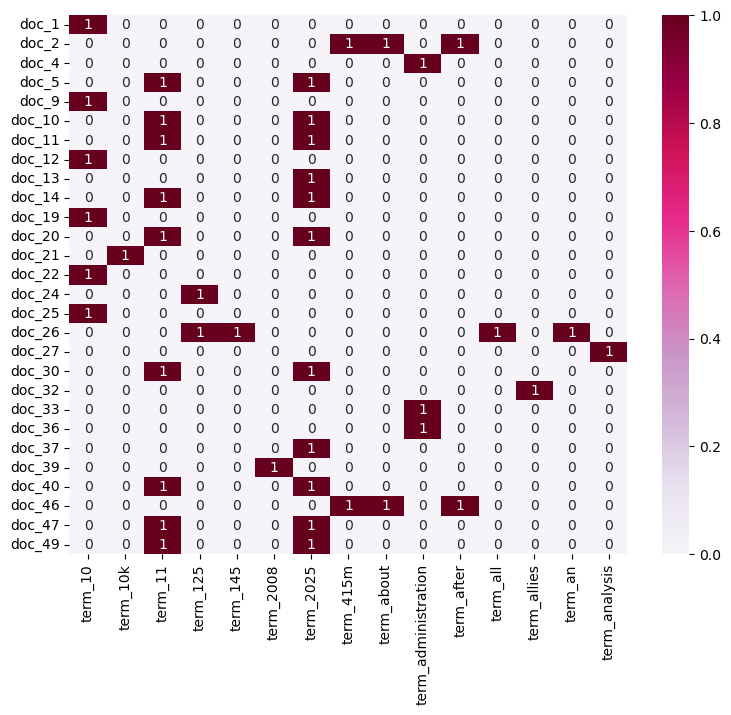

========找出有值的點========
========找出有值的document========
========找出有值的字========


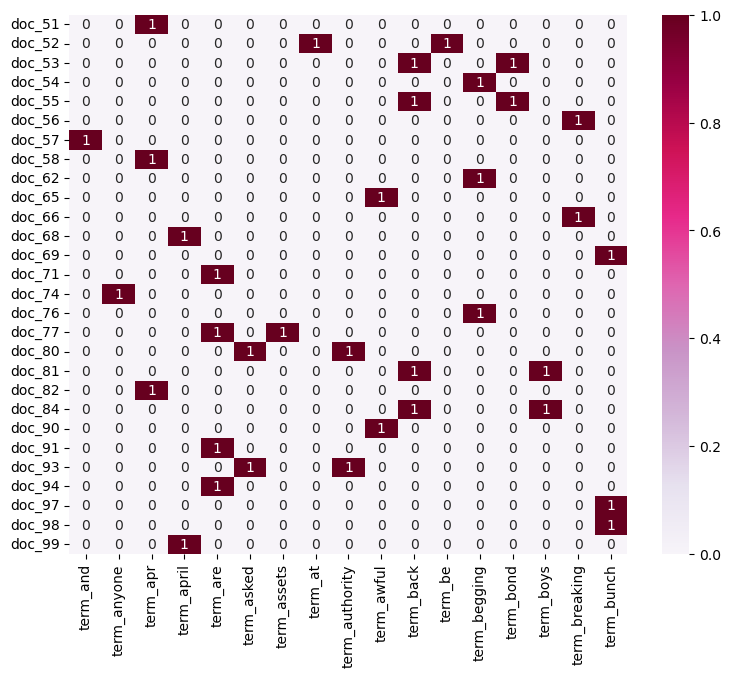

In [19]:
import seaborn as sns
print('''
   因為在這個檔案中，有對應字的doc和對到的字有許多，所以若要以熱度突來呈現，一次呈現較多，會導致圖混在一起。
   故在本次畫圖中，除了先做資料的篩選之外，演示了繪製多張圖以解決此問題的方式 
''')

arr= X_counts_title[0:50, 0:50].toarray()
print("========找出有值的點========")
rows, cols = np.where(arr == 1)
positions = list(zip(rows, cols))

print("========找出有值的document========")
rows_from_positions = [row for row, col in positions]
use_rows = sorted(set(rows_from_positions))

print("========找出有值的字========")
cols_from_positions = [col for row, col in positions]
use_cols = sorted(set(cols_from_positions))

plot_1 = ["term_"+str(i) for i in count_vect_title.get_feature_names_out()[0:50]]
plot_2 = ["doc_"+ str(i) for i in list(X.index)[0:50]]
# plot_3 = X_counts[0:100, 0:100].toarray()  #X_counts[how many documents, how many terms]

df_todraw = pd.DataFrame(arr, columns = plot_1, index = plot_2)
df_selected = df_todraw.iloc[use_rows, use_cols]

plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_selected,
                 cmap="PuRd",
                 annot=True)
plt.show()

arr= X_counts_title[50:100, 50:100].toarray()
print("========找出有值的點========")
rows, cols = np.where(arr == 1)
positions = list(zip(rows, cols))

print("========找出有值的document========")
rows_from_positions = [row for row, col in positions]
use_rows = sorted(set(rows_from_positions))

print("========找出有值的字========")
cols_from_positions = [col for row, col in positions]
use_cols = sorted(set(cols_from_positions))

plot_1 = ["term_"+str(i) for i in count_vect_title.get_feature_names_out()[50:100]]
plot_2 = ["doc_"+ str(i) for i in list(X.index)[50:100]]
# plot_3 = X_counts[0:100, 0:100].toarray()  #X_counts[how many documents, how many terms]

df_todraw = pd.DataFrame(arr, columns = plot_1, index = plot_2)
df_selected = df_todraw.iloc[use_rows, use_cols]

plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_selected,
                 cmap="PuRd",
                 annot=True)
plt.show()


   因為在這個檔案中，有對應字的doc和對到的字有許多，所以若要以熱度突來呈現，一次呈現較多，會導致圖混在一起。
   故在本次畫圖中，除了先做資料的篩選之外，演示了繪製多張圖以解決此問題的方式。
   又從此圖可以觀察到，雖然與上方title使用同樣的繪圖方式與篩選資料數量、方法，但是兩者的資料型態不一，
   text中 0~50的doc中，有許多沒有對應的字詞，被篩選掉了，所以圖呈現較大的色塊，50~100則否。

========找出有值的點========
========找出有值的document========
========找出有值的字========


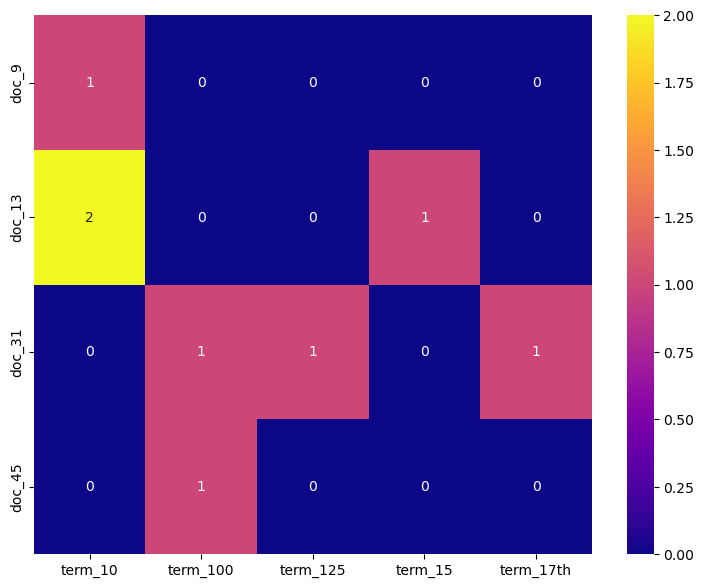

========找出有值的點========
========找出有值的document========
========找出有值的字========


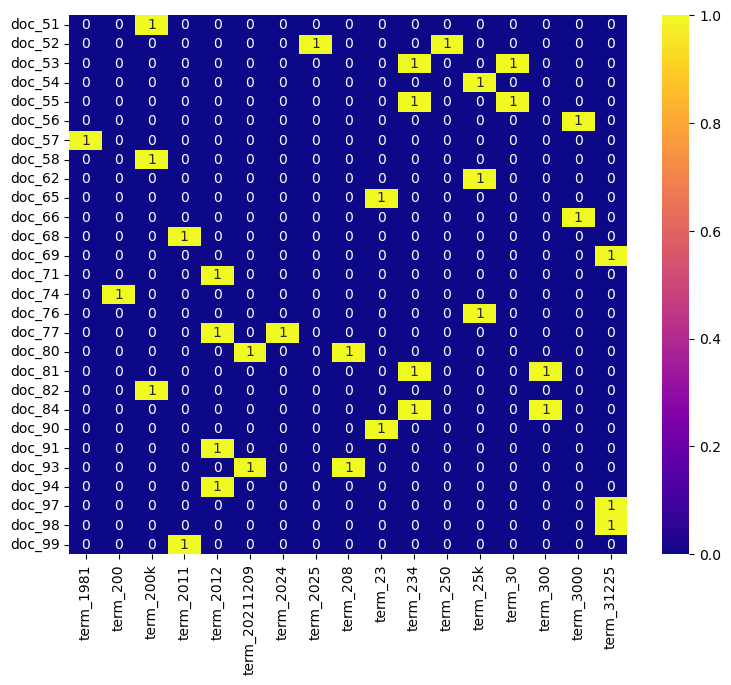

In [20]:
import seaborn as sns
print('''
   因為在這個檔案中，有對應字的doc和對到的字有許多，所以若要以熱度突來呈現，一次呈現較多，會導致圖混在一起。
   故在本次畫圖中，除了先做資料的篩選之外，演示了繪製多張圖以解決此問題的方式。
   又從此圖可以觀察到，雖然與上方title使用同樣的繪圖方式與篩選資料數量、方法，但是兩者的資料型態不一，
   text中 0~50的doc中，有許多沒有對應的字詞，被篩選掉了，所以圖呈現較大的色塊，50~100則否。
''')

arr= X_counts_text[0:50, 0:50].toarray()
print("========找出有值的點========")
rows, cols = np.where(arr == 1)
positions = list(zip(rows, cols))

print("========找出有值的document========")
rows_from_positions = [row for row, col in positions]
use_rows = sorted(set(rows_from_positions))

print("========找出有值的字========")
cols_from_positions = [col for row, col in positions]
use_cols = sorted(set(cols_from_positions))

plot_1 = ["term_"+str(i) for i in count_vect_text.get_feature_names_out()[0:50]]
plot_2 = ["doc_"+ str(i) for i in list(X.index)[0:50]]
# plot_3 = X_counts[0:100, 0:100].toarray()  #X_counts[how many documents, how many terms]

df_todraw = pd.DataFrame(arr, columns = plot_1, index = plot_2)
df_selected = df_todraw.iloc[use_rows, use_cols]

plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_selected,
                 cmap="plasma",
                 annot=True)
plt.show()

arr= X_counts_title[50:100, 50:100].toarray()
print("========找出有值的點========")
rows, cols = np.where(arr == 1)
positions = list(zip(rows, cols))

print("========找出有值的document========")
rows_from_positions = [row for row, col in positions]
use_rows = sorted(set(rows_from_positions))

print("========找出有值的字========")
cols_from_positions = [col for row, col in positions]
use_cols = sorted(set(cols_from_positions))

plot_1 = ["term_"+str(i) for i in count_vect_text.get_feature_names_out()[50:100]]
plot_2 = ["doc_"+ str(i) for i in list(X.index)[50:100]]
# plot_3 = X_counts[0:100, 0:100].toarray()  #X_counts[how many documents, how many terms]

df_todraw = pd.DataFrame(arr, columns = plot_1, index = plot_2)
df_selected = df_todraw.iloc[use_rows, use_cols]

plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_selected,
                 cmap="plasma",
                 annot=True)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22256\2607254563.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(count_vect_title.get_feature_names_out()[:600], rotation = 90);


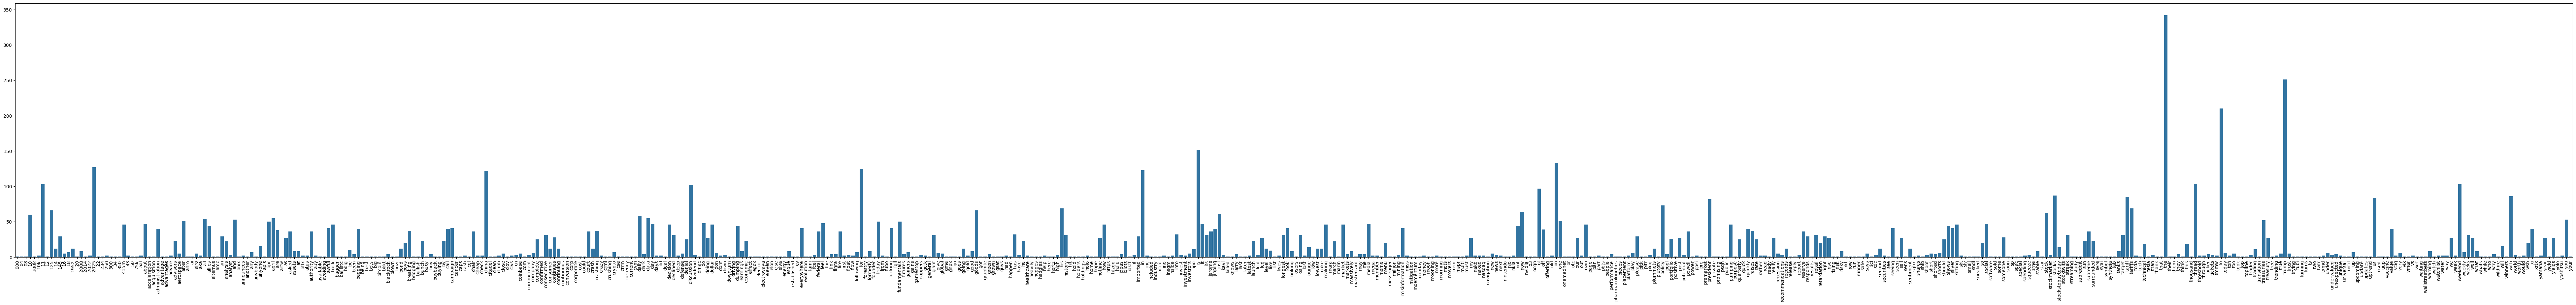

['000' '04' '08' '10' '100k' '10k' '11' '12' '125' '14' '145' '16' '18'
 '1952' '20' '2008' '2014' '2022' '2025' '22' '234' '250' '300' '34' '350'
 '415m' '43' '50' '75k' 'aal' 'about' 'acceleration' 'acquisition'
 'administration' 'advantage' 'advantages' 'advice' 'advisors' 'aerospace'
 'after' 'ahro' 'ai' 'airo' 'aka' 'all' 'allies' 'alternus' 'amc' 'an'
 'analysis' 'analyst' 'and' 'anix' 'announces' 'another' 'any' 'anybody'
 'anyone' 'apls' 'apr' 'april' 'are' 'artw' 'as' 'asked' 'assets' 'at'
 'atlx' 'atus' 'authority' 'auy' 'available' 'avoiding' 'awful' 'back'
 'bagger' 'ballistc' 'bbig' 'be' 'been' 'begging' 'being' 'best' 'bets'
 'big' 'bitcoin' 'bkkt' 'blackrock' 'blown' 'bnzi' 'bond' 'boys'
 'breaking' 'bridging' 'bullish' 'bunch' 'busy' 'buy' 'buyback' 'buying'
 'by' 'call' 'campaign' 'cancer' 'caps' 'cash' 'cel' 'chair' 'cheap'
 'check' 'china' 'citadel' 'clean' 'climb' 'close' 'clov' 'clvs' 'cn'
 'coinbase' 'com' 'commitment' 'company' 'complete' 'confirmed'
 'consecutiv

In [21]:
term_freq_title = []
for j in range(0,X_counts_title.shape[1]):
    term_freq_title.append(sum(X_counts_title[:,j].toarray()))

term_freq_title = np.asarray(X_counts_title.sum(axis=0))[0]
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect_title.get_feature_names_out()[:600], 
            y=term_freq_title[:600])
g.set_xticklabels(count_vect_title.get_feature_names_out()[:600], rotation = 90);
plt.show()

print(count_vect_title.get_feature_names_out()[:600])

因為Text較多細節較多字，所以在對應字的選擇上，取出比title更大的array以供利用


C:\Users\User\AppData\Local\Temp\ipykernel_22256\1125726915.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(count_vect_text.get_feature_names_out()[:4000], rotation = 90);


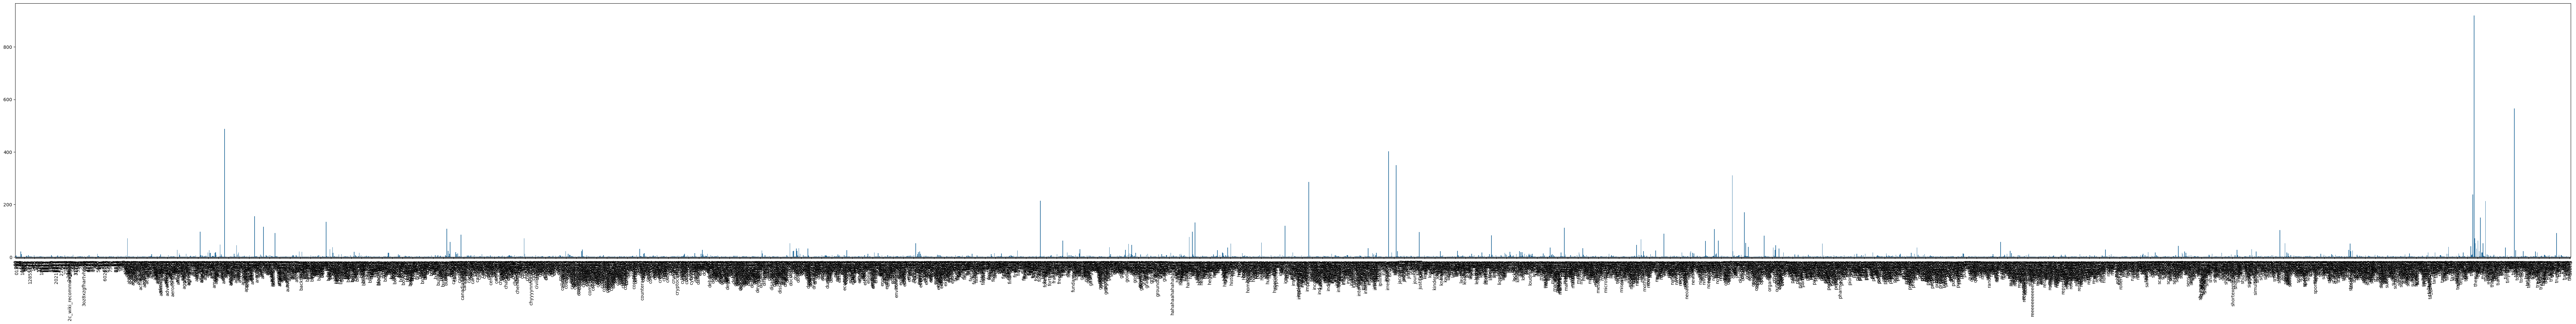

['00' '000' '01378' ... 'twat' 'tweeting' 'tweets']


In [22]:
print("因為Text較多細節較多字，所以在對應字的選擇上，取出比title更大的array以供利用")
term_freq_text = []
for j in range(0,X_counts_text.shape[1]):
    term_freq_text.append(sum(X_counts_text[:,j].toarray()))

term_freq_text = np.asarray(X_counts_text.sum(axis=0))[0]
term_freq_text[0]
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect_text.get_feature_names_out()[:4000], 
            y=term_freq_text[:4000])
g.set_xticklabels(count_vect_text.get_feature_names_out()[:4000], rotation = 90);
plt.show()

print(count_vect_text.get_feature_names_out()[:4000])

In [23]:
import plotly.graph_objects as go

words = count_vect_title.get_feature_names_out()[:600]
freqs = term_freq_title[:600]
indices = list(range(len(words)))  # 0..299

fig = go.Figure(go.Bar(x=words, y=freqs))
fig.update_layout(
    title='600 words_title',
    xaxis=dict(
        tickmode='array',
        tickvals=indices,
        range=[0, 50]
    ),
    width=1050,
    height=600
)


fig.show()

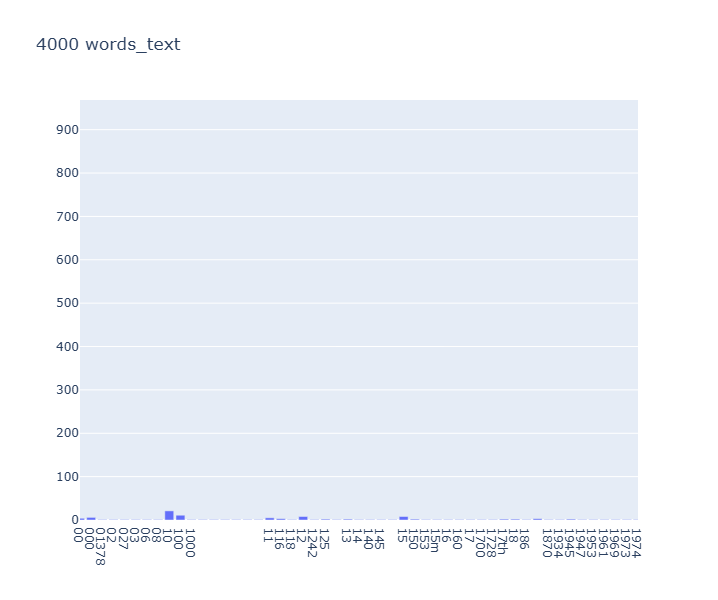

In [24]:
import plotly.graph_objects as go

words = count_vect_text.get_feature_names_out()[:4000]
freqs = term_freq_text[:4000]
indices = list(range(len(words)))  # 0..299

fig = go.Figure(go.Bar(x=words, y=freqs))
fig.update_layout(
    title='4000 words_text',
    xaxis=dict(
        tickmode='array',
        tickvals=indices,
        range=[0, 50]
    ),
    width=1050,
    height=600
)


fig.show()

 先來看看這個freq的資料分布如何，再來決定篩選的門檻值
count    601.000000
mean      14.262895
std       28.937590
min        1.000000
10%        1.000000
25%        1.000000
50%        2.000000
75%       18.000000
90%       44.000000
95%       55.000000
99%      125.000000
max      342.000000
dtype: float64
可以看出這個資料差異沒有特，但詞會用量上有一定比例的差距，決定先用75%=18,先做篩選
決定門檻值，篩出有用、較多的資料
繪圖


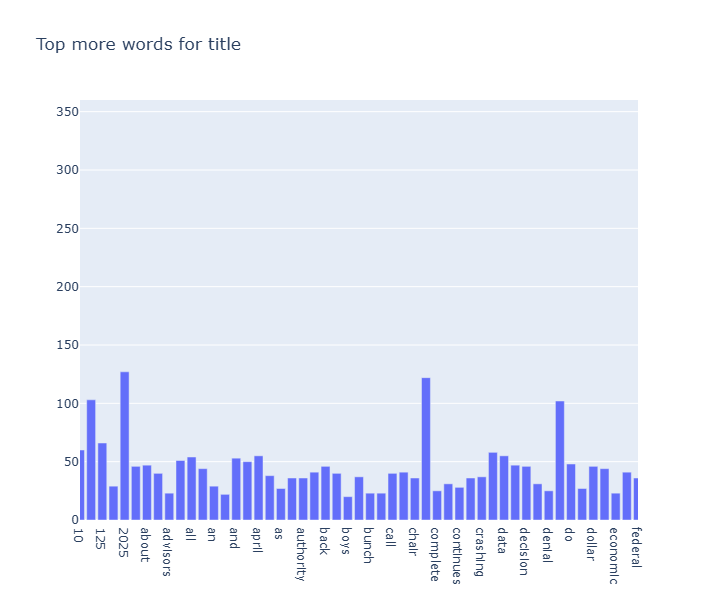

 
經過篩選之後，發現色定的關鍵字常出現在這個論壇上面，像是2025、china、Trump之類的。相比master的資料，大部分可以看出是有特定主題導向的內容，會經常出現在此軟體中。



In [25]:
# Answer here
print(''' 先來看看這個freq的資料分布如何，再來決定篩選的門檻值''')

freq_series_title = pd.Series(term_freq_title)
print(freq_series_title.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

print("可以看出這個資料差異沒有特，但詞會用量上有一定比例的差距，決定先用75%=18,先做篩選")

print("決定門檻值，篩出有用、較多的資料")
more= term_freq_title>18

print("繪圖")
fig = go.Figure(go.Bar(x=count_vect_title.get_feature_names_out()[more], 
                       y=term_freq_title[more]))
fig.update_layout(
    title='Top more words for title',
    xaxis=dict(
        tickmode='array',
        range=[0, 50]
    ),
    width=1050,
    height=600
)


fig.show()

print(''' 
經過篩選之後，發現色定的關鍵字常出現在這個論壇上面，像是2025、china、Trump之類的。相比master的資料，大部分可以看出是有特定主題導向的內容，會經常出現在此軟體中。
''')

 先來看看這個freq的資料分布如何，再來決定篩選的門檻值
count    4346.000000
mean        4.842844
std        23.942440
min         1.000000
10%         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
90%         7.000000
95%        13.000000
99%        62.000000
max       920.000000
dtype: float64
可以看出這個資料差異沒有特，但詞會用量上有一定比例的差距，決定先用90%=7,先做篩選
決定門檻值，篩出有用、較多的資料
繪圖


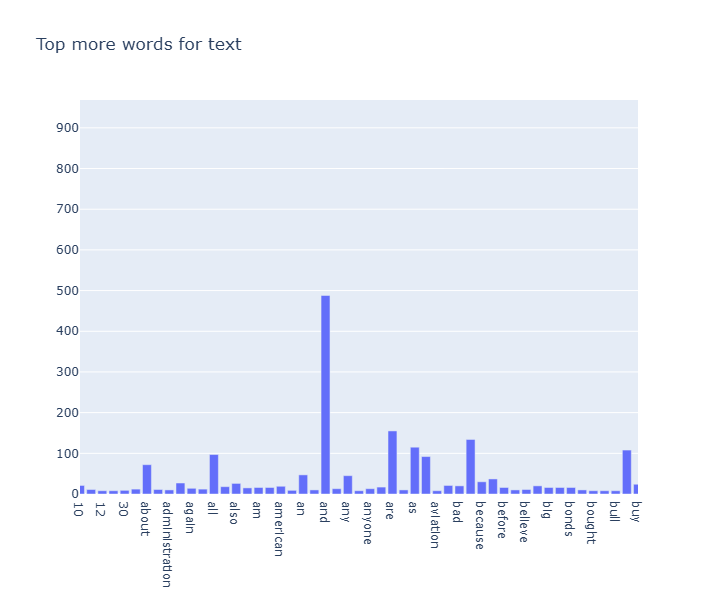

 
在內文的部分，因為有許多文章撰寫需求，出現更多的是介係詞，而非有意義的詞，可以看出title和text顯現出不同的資料特性。



In [26]:
# Answer here
print(''' 先來看看這個freq的資料分布如何，再來決定篩選的門檻值''')

freq_series_text = pd.Series(term_freq_text)
print(freq_series_text.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

print("可以看出這個資料差異沒有特，但詞會用量上有一定比例的差距，決定先用90%=7,先做篩選")

print("決定門檻值，篩出有用、較多的資料")
# 正確的詞頻計算（每個詞 across 所有文件）
more= term_freq_text>7

print("繪圖")
fig = go.Figure(go.Bar(x=count_vect_text.get_feature_names_out()[more], 
                       y=term_freq_text[more]))
fig.update_layout(
    title='Top more words for text',
    xaxis=dict(
        tickmode='array',
        range=[0, 50]
    ),
    width=1050,
    height=600
)


fig.show()

print(''' 
在內文的部分，因為有許多文章撰寫需求，出現更多的是介係詞，而非有意義的詞，可以看出title和text顯現出不同的資料特性。
''')

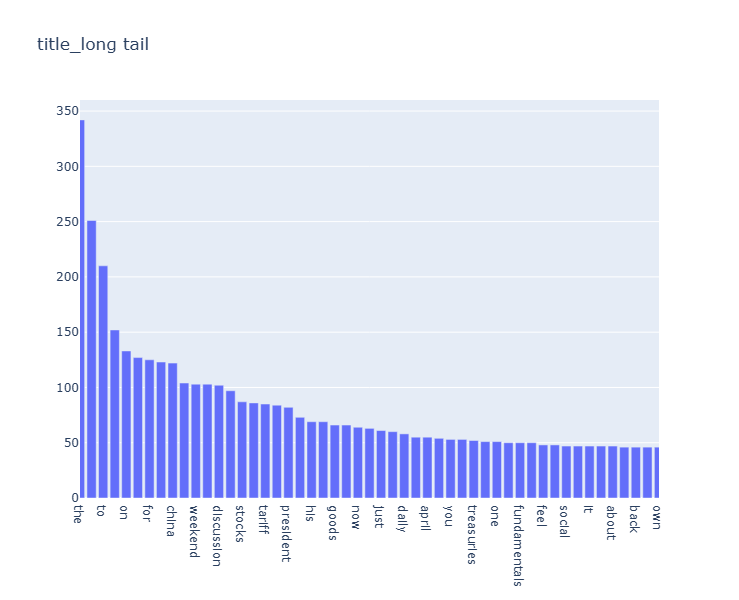

從長尾圖可以看出一些關鍵字對此影響很大，像是trump、china、stocks，因為它使用、出現頻率極高，而請經過長尾圖的排列，可以看出更多數量高低的關係!又因為此為標題，所以這些也是算關鍵字


In [27]:
top=300
indices_title = np.argsort(term_freq_title)[::-1][:top]
word = [count_vect_title.get_feature_names_out()[i] for i in indices_title]
freq = term_freq_title[indices_title]

fig = go.Figure(go.Bar(x=word, 
                       y=freq))
fig.update_layout(
    title='title_long tail',
    xaxis=dict(
        tickmode='array',
        range=[0, 50]
    ),
    width=1050,
    height=600
)


fig.show()

print("從長尾圖可以看出一些關鍵字對此影響很大，像是trump、china、stocks，因為它使用、出現頻率極高，而請經過長尾圖的排列，可以看出更多數量高低的關係!又因為此為標題，所以這些也是算關鍵字")

In [28]:
top=300
indices_text = np.argsort(term_freq_text)[::-1][:top]
word = [count_vect_text.get_feature_names_out()[i] for i in indices_text]
freq = term_freq_text[indices_text]

fig = go.Figure(go.Bar(x=word, 
                       y=freq))
fig.update_layout(
    title='text_long tail',
    xaxis=dict(
        tickmode='array',
        range=[0, 50]
    ),
    width=1050,
    height=600
)


fig.show()

print("從長尾圖可以看出一些關鍵字對此影響很大，但此因為是內文，所以一些句子基本詞彙會出現，但還是可以看到market、trump、china的字樣")

從長尾圖可以看出一些關鍵字對此影響很大，但此因為是內文，所以一些句子基本詞彙會出現，但還是可以看到market、trump、china的字樣


In [29]:
import math
term_freq_title_log = np.array([math.log(i) for i in term_freq_title])
term_freq_text_log = np.array([math.log(i) for i in term_freq_text])

In [30]:
top=300
indices_title = np.argsort(term_freq_title)[::-1][:top]
word = [count_vect_title.get_feature_names_out()[i] for i in indices_title]
freq = term_freq_title_log[indices_title]

fig = go.Figure(go.Bar(x=word, 
                       y=freq))
fig.update_layout(
    title='title_long tail',
    xaxis=dict(
        tickmode='array',
        range=[0, 50]
    ),
    width=1050,
    height=600
)


fig.show()

print("經過取log後，可以看出更明顯的落差，向是this到record之間，有明顯數值變化的趨勢")

經過取log後，可以看出更明顯的落差，向是this到record之間，有明顯數值變化的趨勢


In [31]:
top=300
indices_text = np.argsort(term_freq_text)[::-1][:top]
word = [count_vect_text.get_feature_names_out()[i] for i in indices_text]
freq = term_freq_text_log[indices_text]

fig = go.Figure(go.Bar(x=word, 
                       y=freq))
fig.update_layout(
    title='text_long tail',
    xaxis=dict(
        tickmode='array',
        range=[0, 50]
    ),
    width=1050,
    height=600
)


fig.show()

###  new data visualizations

In [32]:
X

,subreddit,title,text,label,vote,title_p,text_p
0,wallstreetbets,Retardation is on the menu boys! WSB is so back,Calls on retards,-1.0,0.0,"[Retardation, is, on, the, menu, boys, !, WSB,...","[Calls, on, retards]"
1,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Stunt as in like why did they even make a big ...,0.0,-15.0,"[Retail, giant, TARGET, has, now, declined, fo...","[Stunt, as, in, like, why, did, they, even, ma..."
2,StockMarket,How do you feel about a sitting president maki...,Seeing lots of red in the ticker.,0.0,1.0,"[How, do, you, feel, about, a, sitting, presid...","[Seeing, lots, of, red, in, the, ticker, .]"
3,stockstobuytoday,Who knows more? $VMAR,Vision Marine Technologies Inc. is rewriting t...,1.0,30.0,"[Who, knows, more, ?, $, VMAR]","[Vision, Marine, Technologies, Inc., is, rewri..."
4,StockMarket,The Trump administration is begging Xi Jinping...,He didn’t say thank you.,-1.0,1.0,"[The, Trump, administration, is, begging, Xi, ...","[He, didn, ’, t, say, thank, you, .]"
...,...,...,...,...,...,...,...
842,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Invest now it is going to shoot up tomorrow,1.0,1.0,"[$, MRIN, Marin, Software, killed, it, today, ...","[Invest, now, it, is, going, to, shoot, up, to..."
843,StockMarket,$ U.S. dollar value (crashing),Where can I read this?,0.0,2.0,"[$, U.S., dollar, value, (, crashing, )]","[Where, can, I, read, this, ?]"
844,stockstobuytoday,Analyst Recommendations,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.0,1.0,"[Analyst, Recommendations]","[Upgrades, ,, Downgrades, [, Stock, Analyst, R..."
845,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,i sold my puts so i expect cheeto to declare w...,-1.0,10.0,"[Weekend, Discussion, Thread, for, the, Weeken...","[i, sold, my, puts, so, i, expect, cheeto, to,..."


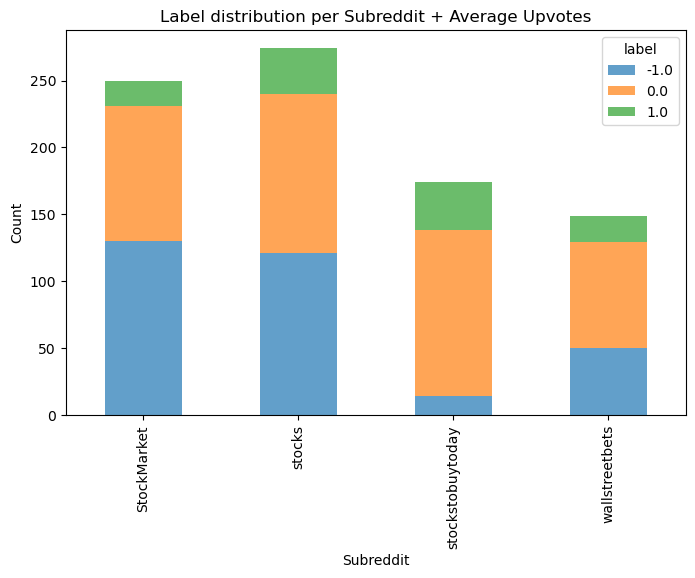

從圖中可以看出，不同論壇間，會出現的label值比例不一樣，所以可以看到，不同論壇之間有明顯的仇恨與否與中立的差異，像是stockstobuytoday就明顯比較少-1.0的點


In [33]:
fig, ax = plt.subplots(figsize=(8,5))

label_counts = X.groupby(["subreddit","label"]).size().unstack(fill_value=0)

label_counts.plot(kind="bar", stacked=True, ax=ax, alpha=0.7)
ax.set_ylabel("Count")
ax.set_xlabel("Subreddit")


plt.title("Label distribution per Subreddit + Average Upvotes")
plt.show()

print("從圖中可以看出，不同論壇間，會出現的label值比例不一樣，所以可以看到，不同論壇之間有明顯的仇恨與否與中立的差異，像是stockstobuytoday就明顯比較少-1.0的點")

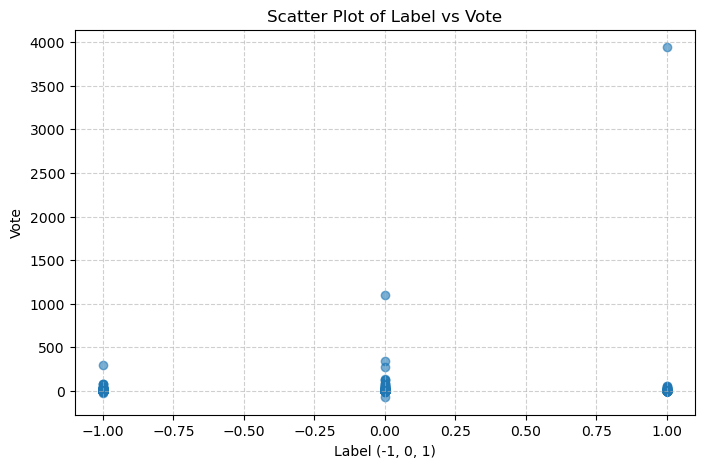



  透過此圖來看到文章按讚數和統計出來label情緒正負的相關性。
  從此圖可以看出來，0.0和0.1有較多的按讚數，但是這可能取決於該篇文章的互動程度導致。或許可以推測平台較少推送-1.0的貼文，傳播負面的資訊。
  但因為這裡有極端值的互動值，所以看不太清楚較少按讚數的情況，故下面篩除極端值後呈現。


In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(X['label'], X['vote'], alpha=0.6)

plt.title("Scatter Plot of Label vs Vote")
plt.xlabel("Label (-1, 0, 1)")
plt.ylabel("Vote")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print('''

  透過此圖來看到文章按讚數和統計出來label情緒正負的相關性。
  從此圖可以看出來，0.0和0.1有較多的按讚數，但是這可能取決於該篇文章的互動程度導致。或許可以推測平台較少推送-1.0的貼文，傳播負面的資訊。
  但因為這裡有極端值的互動值，所以看不太清楚較少按讚數的情況，故下面篩除極端值後呈現。''')

In [35]:
# 假設我們認定 vote 絕對值超過 200 的都是極端值
X_filtered = X[abs(X['vote']) <= 100]

print("原始資料筆數:", len(X))
print("過濾後筆數:", len(X_filtered))


原始資料筆數: 847
過濾後筆數: 839


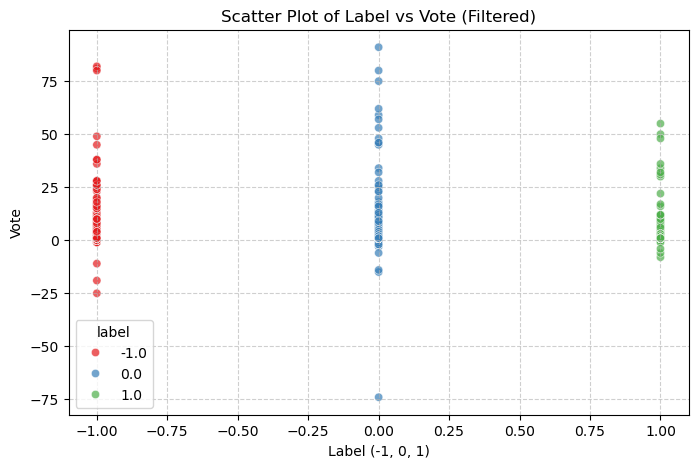


   從此圖中可以看出來，在label=-1.0的值中，可以看到較多的負數vote，在0.00也有一個負數許多的。




In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=X_filtered, x="label", y="vote", hue="label", palette="Set1", alpha=0.7)

plt.title("Scatter Plot of Label vs Vote (Filtered)")
plt.xlabel("Label (-1, 0, 1)")
plt.ylabel("Vote")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print('''
   從此圖中可以看出來，在label=-1.0的值中，可以看到較多的負數vote，在0.00也有一個負數許多的。

''')

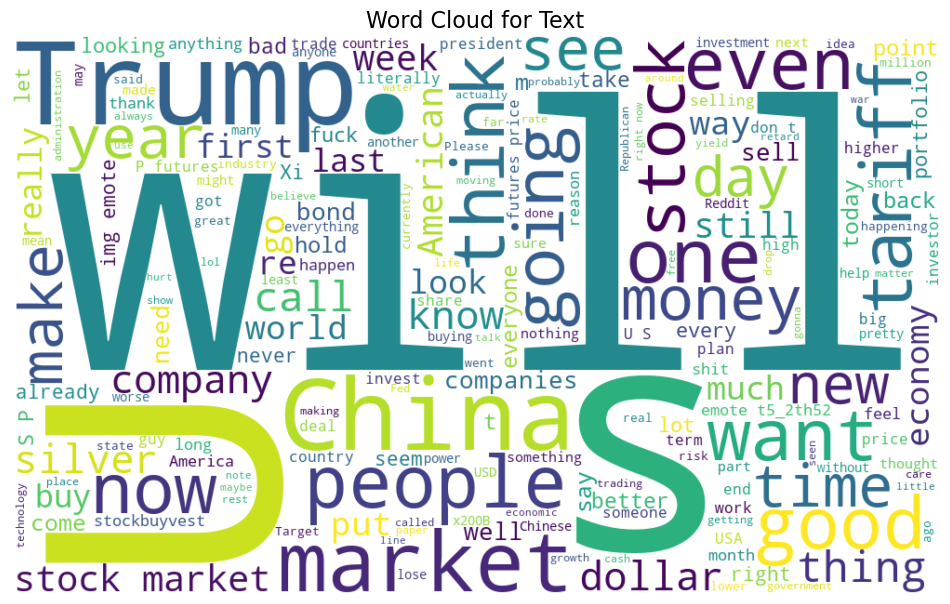

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_data = " ".join(X["text"].dropna().astype(str))

wc = WordCloud(width=1000, height=600, background_color="white", colormap="viridis").generate(text_data)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Text", fontsize=16)
plt.show()


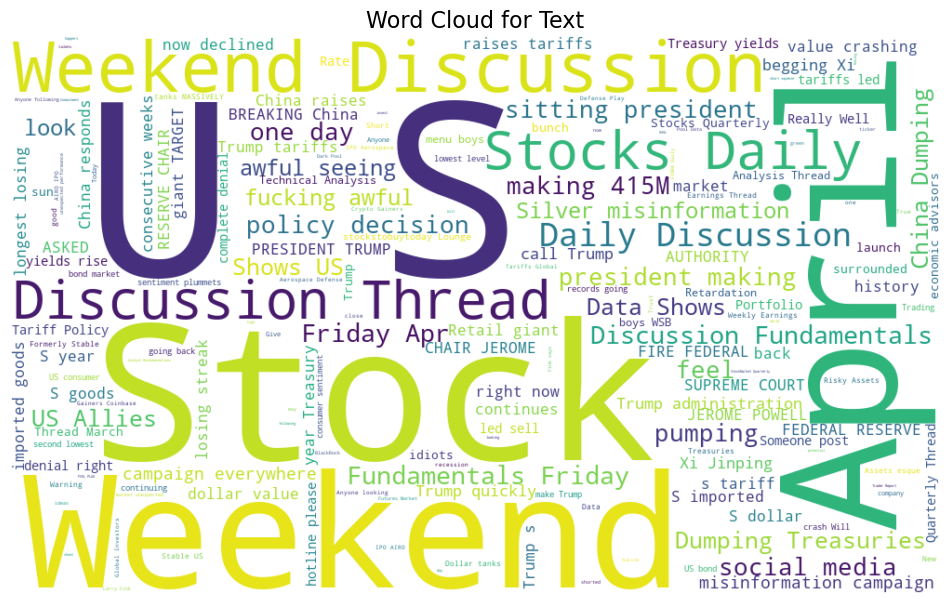

In [38]:
text_data = " ".join(X["title"].dropna().astype(str))

wc = WordCloud(width=1000, height=600, background_color="white", colormap="viridis").generate(text_data)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Text", fontsize=16)
plt.show()


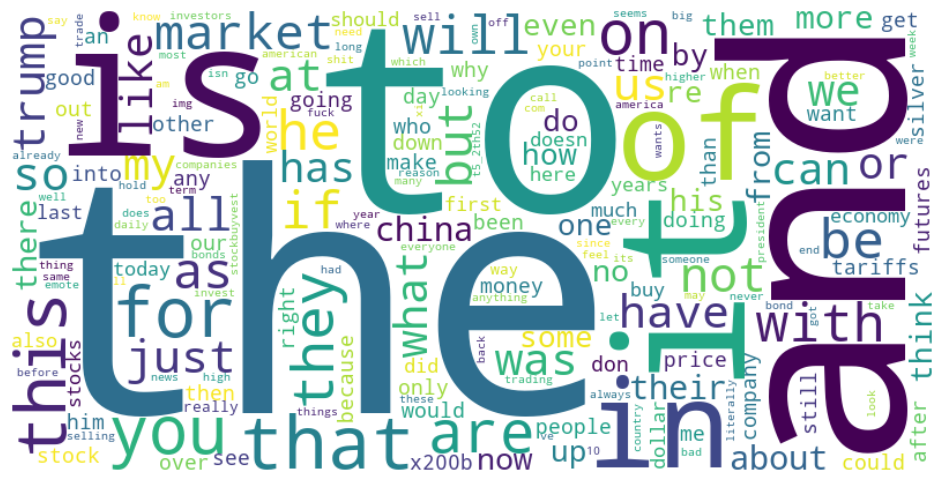

In [39]:
more = term_freq_text > 7 
words = count_vect_text.get_feature_names_out()[more]
freqs = term_freq_text[more]

freq_dict = dict(zip(words, freqs))

wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(freq_dict)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


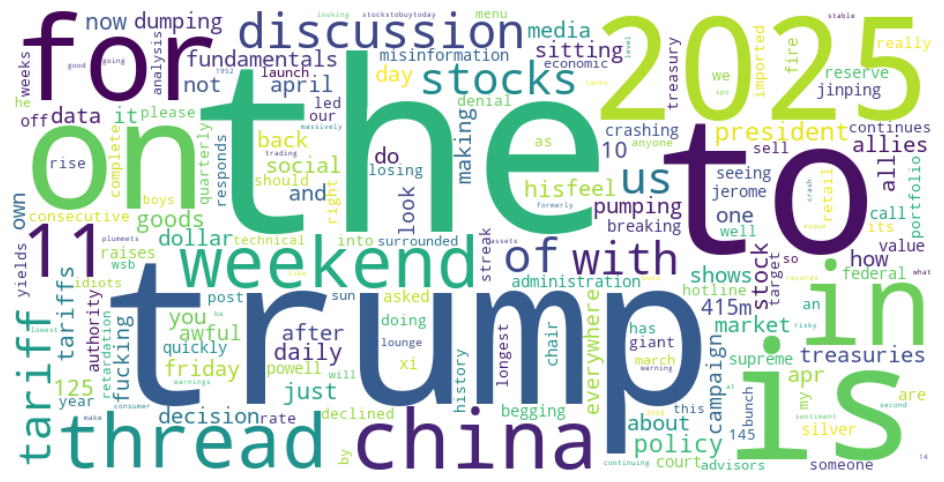

In [40]:
more = term_freq_title > 7  # 
words = count_vect_title.get_feature_names_out()[more]
freqs = term_freq_title[more]

freq_dict = dict(zip(words, freqs))

wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(freq_dict)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


# Phase 2

In [ ]:
### Begin Assignment Here